# 中文字体显示测试

本 notebook 用于测试 matplotlib 中文字体是否正确配置和显示。


In [3]:
import matplotlib.pyplot as plt
import matplotlib

# 配置中文字体（简单方法）
matplotlib.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'SimSun', 'Arial Unicode MS']
matplotlib.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

print("✓ 中文字体已配置")
print(f"当前字体设置: {matplotlib.rcParams['font.sans-serif']}")


✓ 中文字体已配置
当前字体设置: ['Microsoft YaHei', 'SimHei', 'SimSun', 'Arial Unicode MS']


## 检查当前使用的字体


In [1]:
# 检查当前 matplotlib 使用的字体
from matplotlib.font_manager import findfont, FontProperties

test_text = '测试'
current_font = findfont(FontProperties(family='sans-serif'))
print(f"当前使用的字体文件: {current_font}")

# 测试字体是否能显示中文
try:
    fig, ax = plt.subplots(figsize=(6, 2))
    ax.text(0.5, 0.5, test_text, fontsize=30, ha='center', va='center')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    plt.show()
    print("✓ 字体测试成功")
except Exception as e:
    print(f"✗ 字体测试失败: {e}")


ValueError: 
sans-serif
    ^
ParseException: Expected end of text, found '-'  (at char 4), (line:1, col:5)

## 测试1: 简单文本显示


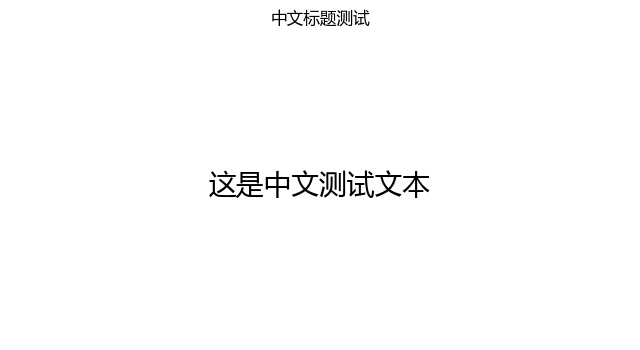

如果看到正常的中文，说明字体配置成功！


In [5]:
# 测试中文文本
fig, ax = plt.subplots(figsize=(8, 4))
ax.text(0.5, 0.5, '这是中文测试文本', fontsize=20, ha='center', va='center')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')
plt.title('中文标题测试')
plt.show()
print("如果看到正常的中文，说明字体配置成功！")


## 测试2: 图表中的中文显示


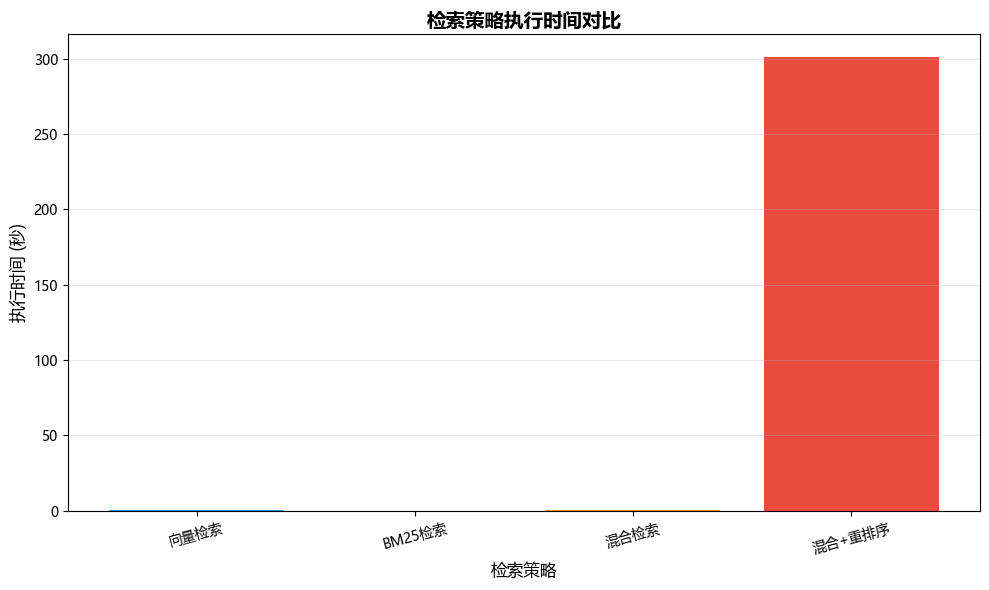

如果图表中的中文正常显示，说明配置成功！


In [6]:
# 测试柱状图
fig, ax = plt.subplots(figsize=(10, 6))

categories = ['向量检索', 'BM25检索', '混合检索', '混合+重排序']
values = [0.32, 0.05, 0.20, 301.05]

ax.bar(categories, values, color=['#3498db', '#2ecc71', '#f39c12', '#e74c3c'])
ax.set_title('检索策略执行时间对比', fontsize=14, fontweight='bold')
ax.set_xlabel('检索策略', fontsize=12)
ax.set_ylabel('执行时间 (秒)', fontsize=12)
ax.grid(axis='y', alpha=0.3)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("如果图表中的中文正常显示，说明配置成功！")


## 测试3: 多子图中文显示


C:\Users\lenovo\AppData\Local\Temp\ipykernel_19084\647728799.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1, 1].boxplot(data, labels=['策略A', '策略B', '策略C'])


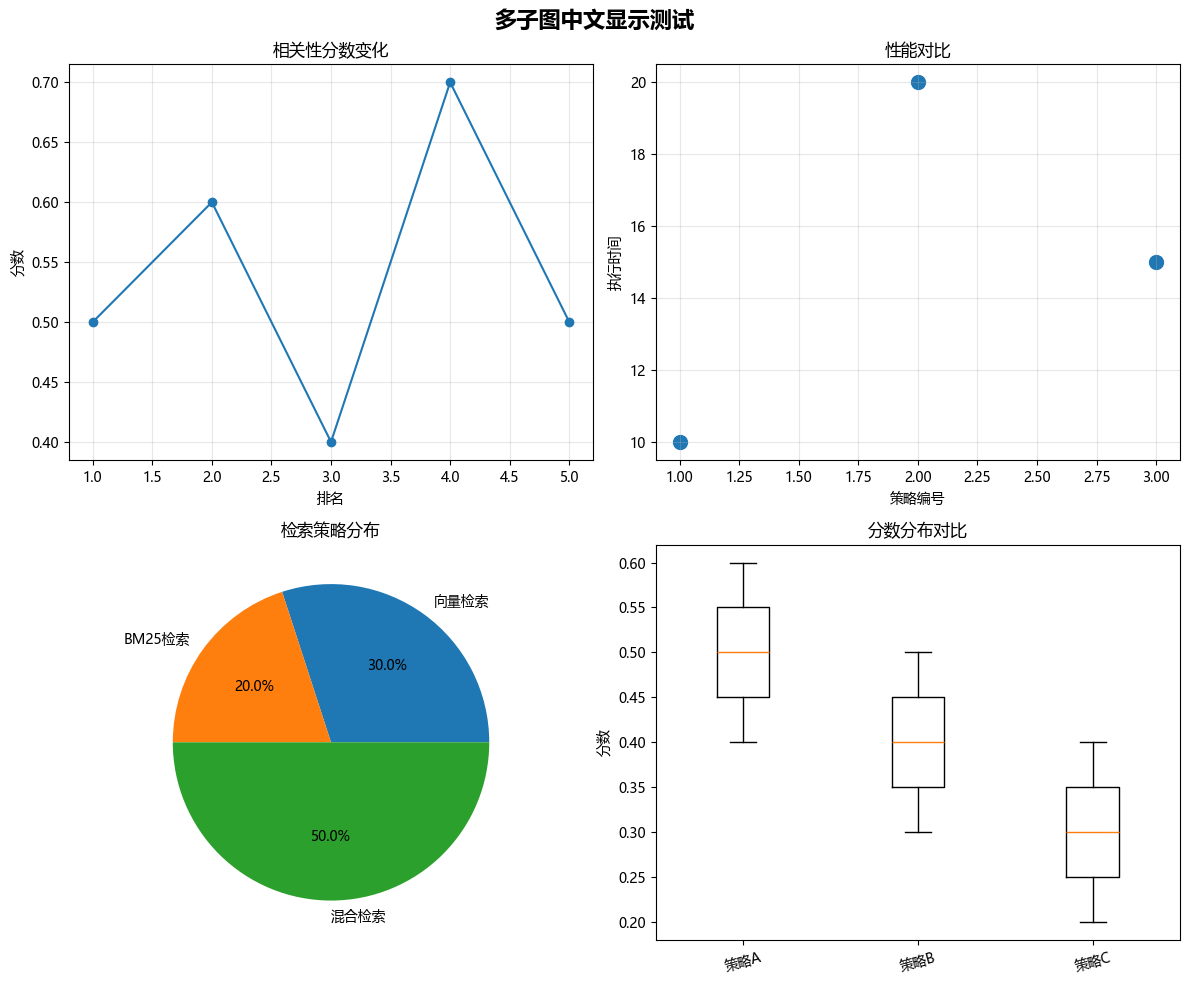

如果所有子图的中文都正常显示，说明配置完全成功！


In [7]:
# 测试多子图
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('多子图中文显示测试', fontsize=16, fontweight='bold')

# 子图1: 折线图
x = [1, 2, 3, 4, 5]
y = [0.5, 0.6, 0.4, 0.7, 0.5]
axes[0, 0].plot(x, y, marker='o')
axes[0, 0].set_title('相关性分数变化')
axes[0, 0].set_xlabel('排名')
axes[0, 0].set_ylabel('分数')
axes[0, 0].grid(alpha=0.3)

# 子图2: 散点图
axes[0, 1].scatter([1, 2, 3], [10, 20, 15], s=100)
axes[0, 1].set_title('性能对比')
axes[0, 1].set_xlabel('策略编号')
axes[0, 1].set_ylabel('执行时间')
axes[0, 1].grid(alpha=0.3)

# 子图3: 饼图
labels = ['向量检索', 'BM25检索', '混合检索']
sizes = [30, 20, 50]
axes[1, 0].pie(sizes, labels=labels, autopct='%1.1f%%')
axes[1, 0].set_title('检索策略分布')

# 子图4: 箱线图
data = [[0.5, 0.6, 0.4], [0.3, 0.4, 0.5], [0.2, 0.3, 0.4]]
axes[1, 1].boxplot(data, labels=['策略A', '策略B', '策略C'])
axes[1, 1].set_title('分数分布对比')
axes[1, 1].set_ylabel('分数')
axes[1, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print("如果所有子图的中文都正常显示，说明配置完全成功！")


## 测试4: 图例中的中文


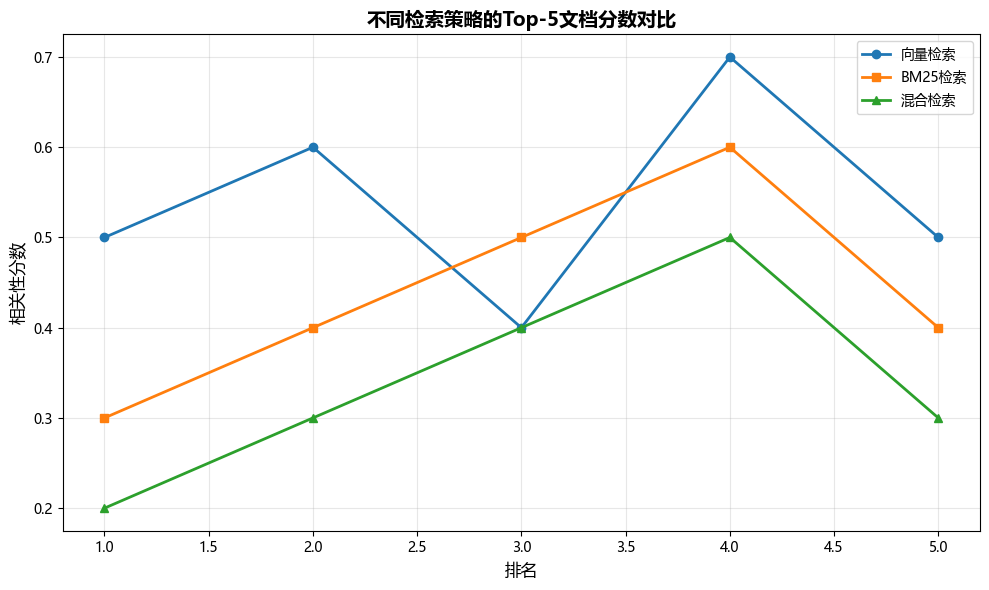

如果图例中的中文正常显示，说明配置成功！


In [8]:
# 测试图例
fig, ax = plt.subplots(figsize=(10, 6))

x = range(1, 6)
y1 = [0.5, 0.6, 0.4, 0.7, 0.5]
y2 = [0.3, 0.4, 0.5, 0.6, 0.4]
y3 = [0.2, 0.3, 0.4, 0.5, 0.3]

ax.plot(x, y1, marker='o', label='向量检索', linewidth=2)
ax.plot(x, y2, marker='s', label='BM25检索', linewidth=2)
ax.plot(x, y3, marker='^', label='混合检索', linewidth=2)

ax.set_title('不同检索策略的Top-5文档分数对比', fontsize=14, fontweight='bold')
ax.set_xlabel('排名', fontsize=12)
ax.set_ylabel('相关性分数', fontsize=12)
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("如果图例中的中文正常显示，说明配置成功！")


## 故障排查

如果中文仍然显示为方框，请尝试：

1. **重启 Jupyter Kernel**（最重要）
   - 在 Jupyter 菜单：Kernel -> Restart Kernel
   - 然后重新运行所有单元格

2. **检查系统字体**
   - Windows: 打开"字体"设置，确认是否安装了 Microsoft YaHei（微软雅黑）
   - 如果没有，可以安装中文字体

3. **清除 matplotlib 缓存**
   ```python
   import matplotlib
   import os
   cache_dir = matplotlib.get_cachedir()
   # 删除缓存目录中的字体相关文件
   ```

4. **手动指定字体路径**（如果上述方法都不行）
   ```python
   from matplotlib.font_manager import FontProperties
   font = FontProperties(fname='C:/Windows/Fonts/msyh.ttc')  # 微软雅黑路径
   ax.set_title('标题', fontproperties=font)
   ```
